# Customer Churn Prediction for Telecom Companies

**Capstone Project — Predictive Analytics**

**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Objective:** Predict which customers are likely to churn using Machine Learning

1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training & Evaluation
6. Model Comparison
7. Feature Importance & Interpretation
8. Conclusions & Recommendations

In [1]:
#Step 1: Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

# Additional
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
})

COLORS = {
    'primary': '#667eea',
    'secondary': '#764ba2',
    'success': '#43e97b',
    'danger': '#f5576c',
    'warning': '#f7971e',
    'info': '#4facfe',
    'churn': ['#43e97b', '#f5576c'],  # No, Yes
}

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
#Step 2: Load the dataset
df = pd.read_csv('/workspaces/Predictive_Analytics_Project_1/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
# Check unique values for each column
print("Unique Values per Column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique → {df[col].unique()[:5]}...")

Unique Values per Column:
  customerID: 7043 unique → <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU']
Length: 5, dtype: str...
  gender: 2 unique → <StringArray>
['Female', 'Male']
Length: 2, dtype: str...
  SeniorCitizen: 2 unique → [0 1]...
  Partner: 2 unique → <StringArray>
['Yes', 'No']
Length: 2, dtype: str...
  Dependents: 2 unique → <StringArray>
['No', 'Yes']
Length: 2, dtype: str...
  tenure: 73 unique → [ 1 34  2 45  8]...
  PhoneService: 2 unique → <StringArray>
['No', 'Yes']
Length: 2, dtype: str...
  MultipleLines: 3 unique → <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str...
  InternetService: 3 unique → <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str...
  OnlineSecurity: 3 unique → <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str...
  OnlineBackup: 3 unique → <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str...
  DeviceProtection: 3 unique → <String

In [7]:
#Step 3: Data Preprocessing & Data Cleaning
# Fix TotalCharges — has blank strings instead of NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"TotalCharges NaN count: {df['TotalCharges'].isna().sum()}")

# Show the problematic rows
print("\nRows with missing TotalCharges:")
print(df[df['TotalCharges'].isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

TotalCharges NaN count: 11

Rows with missing TotalCharges:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


In [8]:
# Impute missing TotalCharges with tenure * MonthlyCharges
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'tenure'] * df.loc[mask, 'MonthlyCharges']
df['TotalCharges'].fillna(0, inplace=True)

print(f"Missing values after fix: {df['TotalCharges'].isna().sum()}")

Missing values after fix: 0


In [9]:
# Drop customerID (not a feature)
df.drop('customerID', axis=1, inplace=True)
print(f"Shape after dropping customerID: {df.shape}")

Shape after dropping customerID: (7043, 20)


In [10]:
# Convert SeniorCitizen from 0/1 to No/Yes for consistency
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


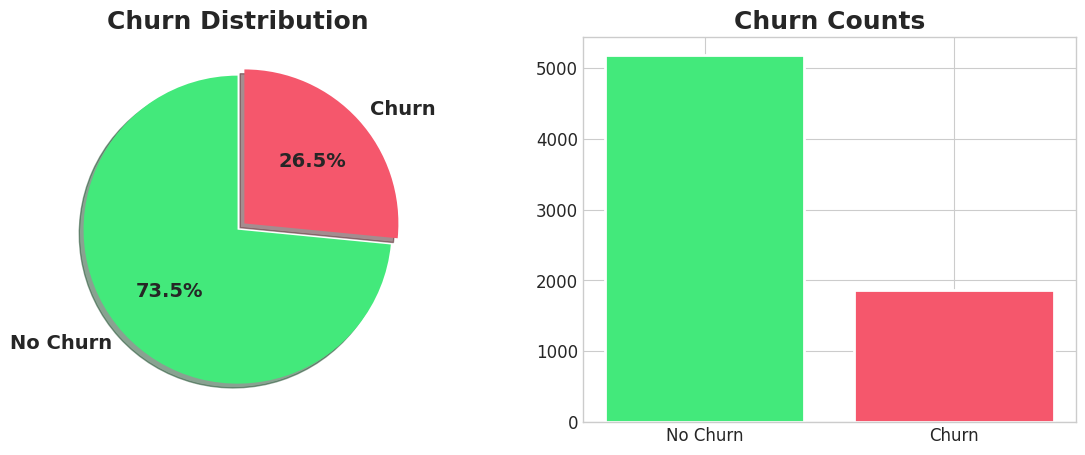


Churn Rate: 26.5%
Class Imbalance Ratio: 2.77:1


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[0].pie(
    churn_counts.values, labels=['No Churn', 'Churn'],
    autopct='%1.1f%%', colors=COLORS['churn'],
    explode=(0, 0.06), shadow=True,
    textprops={'fontsize': 14, 'fontweight': 'bold'},
    startangle=90
)
axes[0].set_title('Churn Distribution', fontsize=18, fontweight='bold')

# Bar chart
bars = axes[1].bar(
    ['No Churn', 'Churn'], churn_counts.values,
    color=COLORS['churn'], edgecolor='white', linewidth=2
)
axes[1].set_title('Churn Counts', fontsize=18, fontweight='bold')



plt.show()

print(f"\nChurn Rate: {churn_counts['Yes'] / len(df) * 100:.1f}%")
print(f"Class Imbalance Ratio: {churn_counts['No'] / churn_counts['Yes']:.2f}:1")

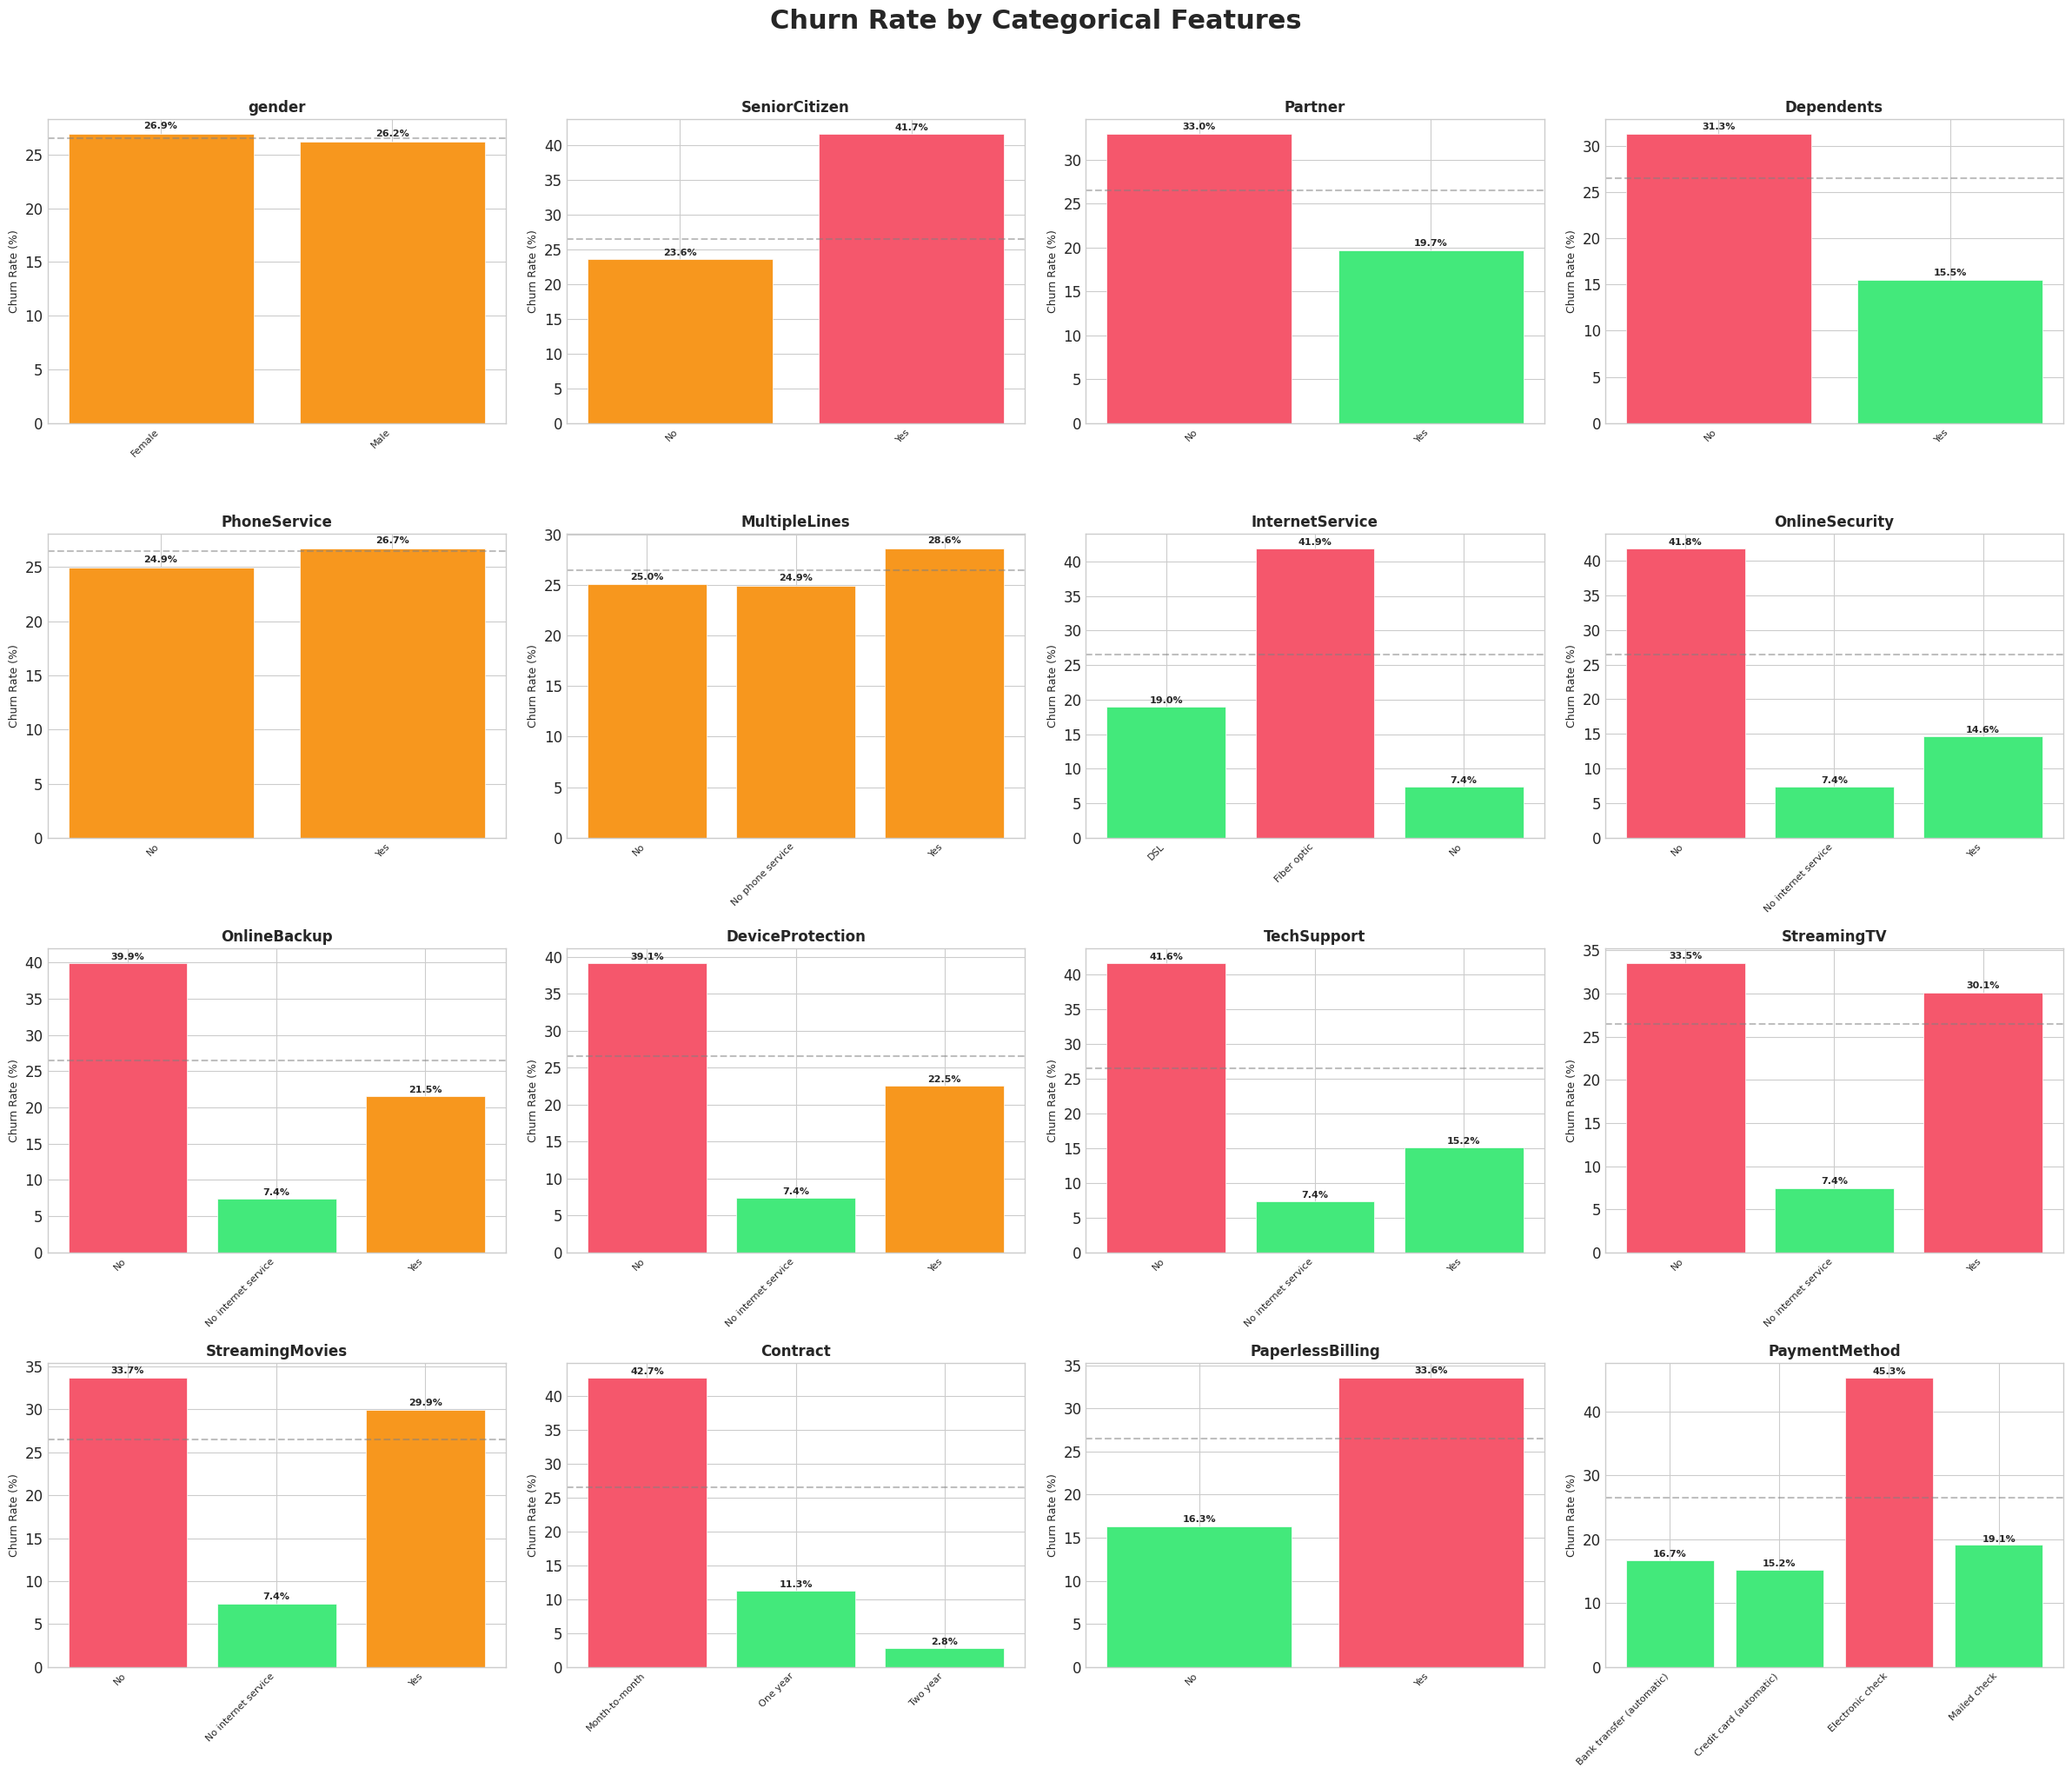

In [18]:
#3.2 Categorical Features Vs Churn
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(24, 20))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    churn_rates = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    bars = axes[i].bar(
        range(len(churn_rates)), churn_rates.values,
        color=[COLORS['danger'] if v > 30 else COLORS['warning'] if v > 20 else COLORS['success'] for v in churn_rates.values],
        edgecolor='white', linewidth=0.5
    )
    axes[i].set_xticks(range(len(churn_rates)))
    axes[i].set_xticklabels(churn_rates.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)', fontsize=9)
    axes[i].axhline(y=26.5, color='gray', linestyle='--', alpha=0.5, label='Avg')
    
    # Add value labels
    for bar, val in zip(bars, churn_rates.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Churn Rate by Categorical Features', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

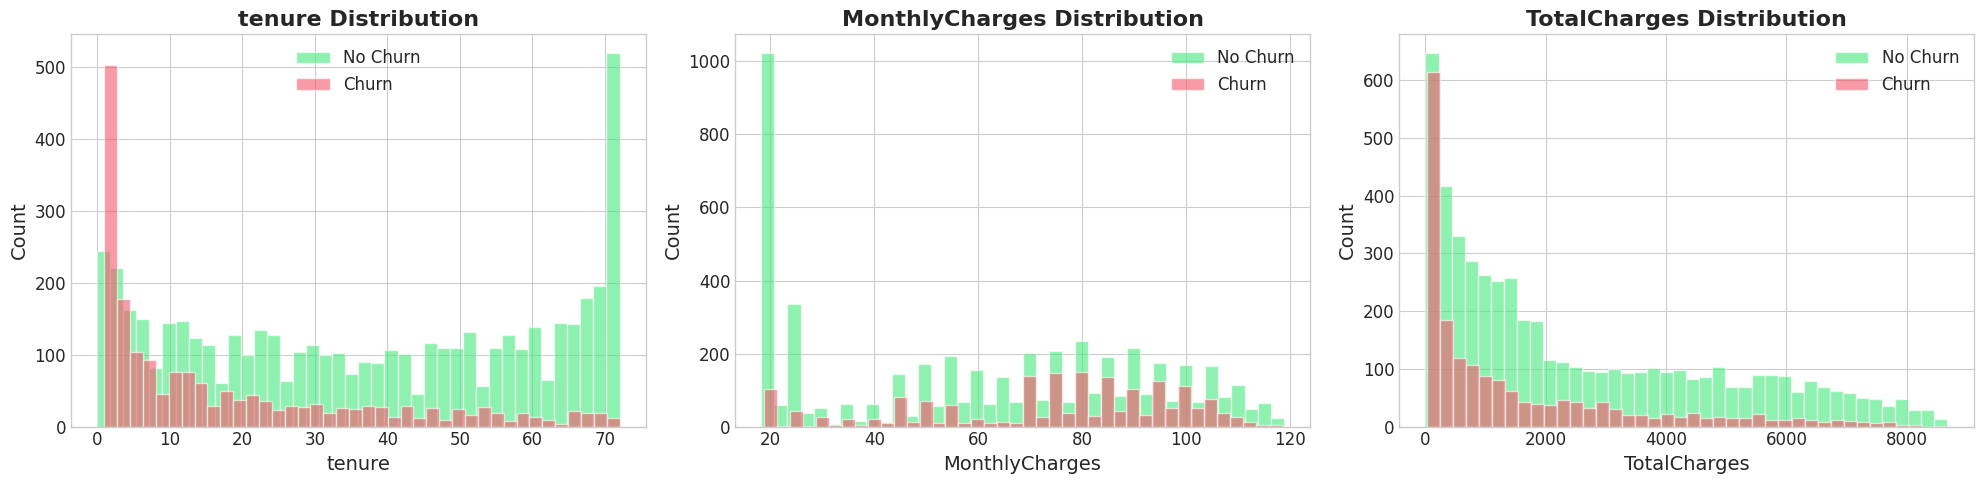

In [13]:
#3.3 Numerical Features Distribution
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(num_cols):
    for churn_val, color, label in [('No', COLORS['success'], 'No Churn'), ('Yes', COLORS['danger'], 'Churn')]:
        subset = df[df['Churn'] == churn_val][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='white')
    
    axes[i].set_title(f'{col} Distribution', fontsize=16, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.show()

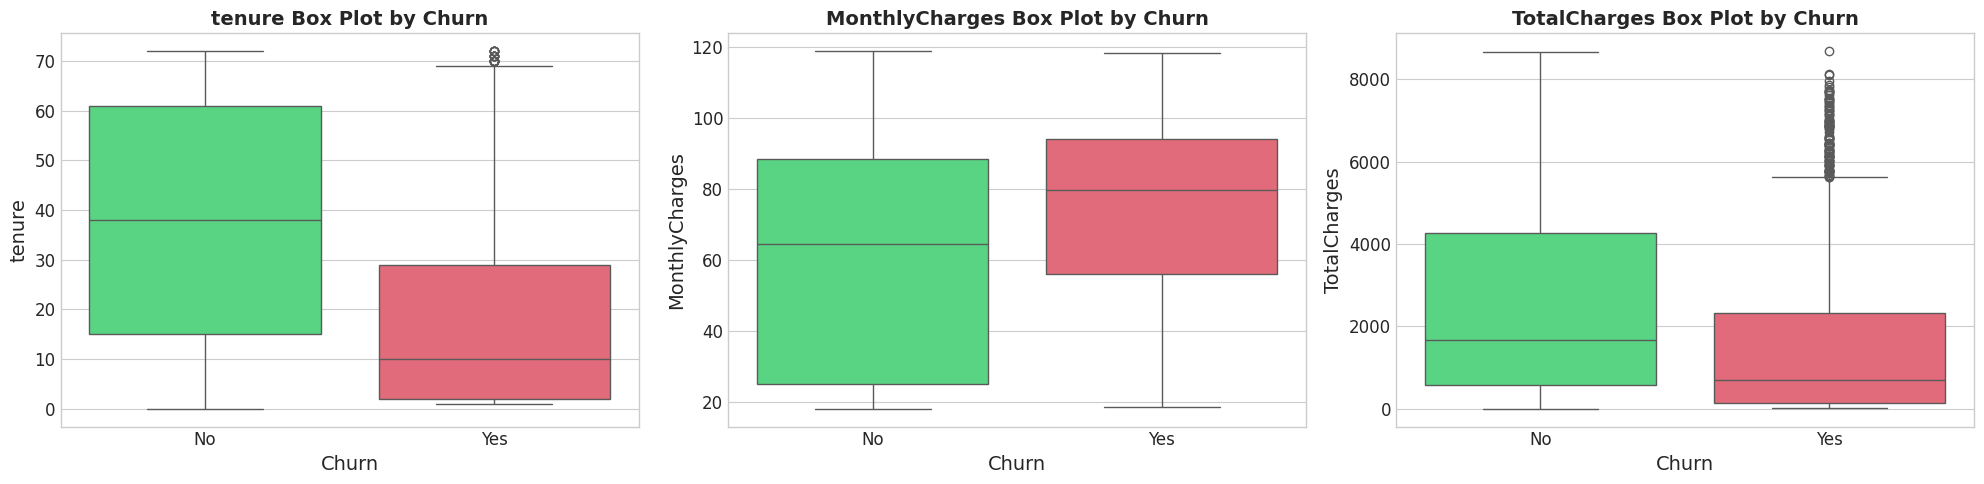

In [14]:
#Box plots for numerical features
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette=COLORS['churn'])
    axes[i].set_title(f'{col} Box Plot by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

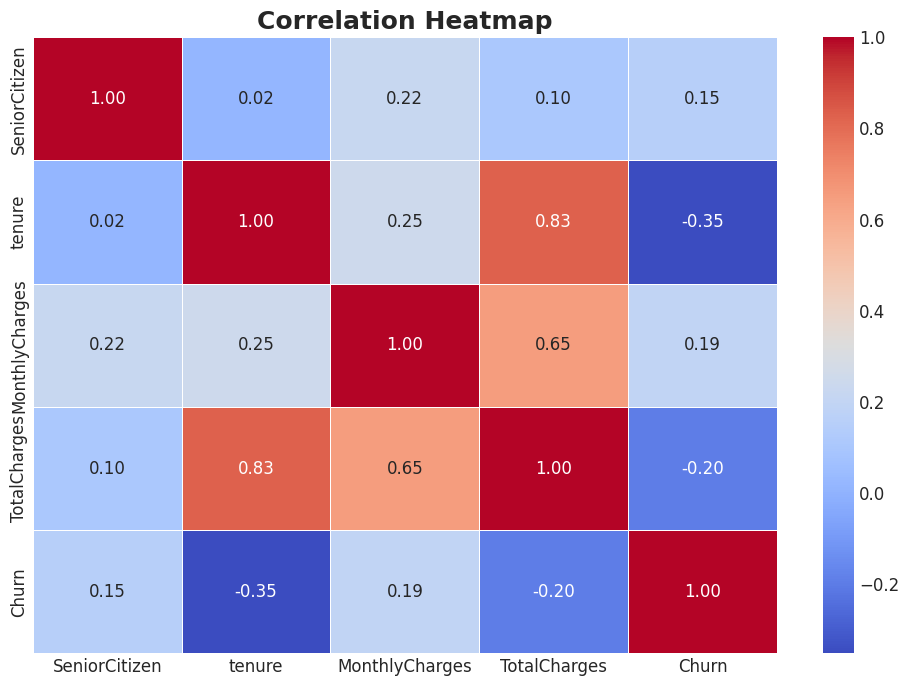

In [15]:
#3.4 Correlation Heatmap
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'No': 0, 'Yes': 1})
df_corr['SeniorCitizen'] = df_corr['SeniorCitizen'].map({'No': 0, 'Yes': 1})
numeric_df = df_corr.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=18,   fontweight='bold')
plt.show()


Correlation with Churn:
tenure           -0.352229
TotalCharges     -0.198324
SeniorCitizen     0.150889
MonthlyCharges    0.193356


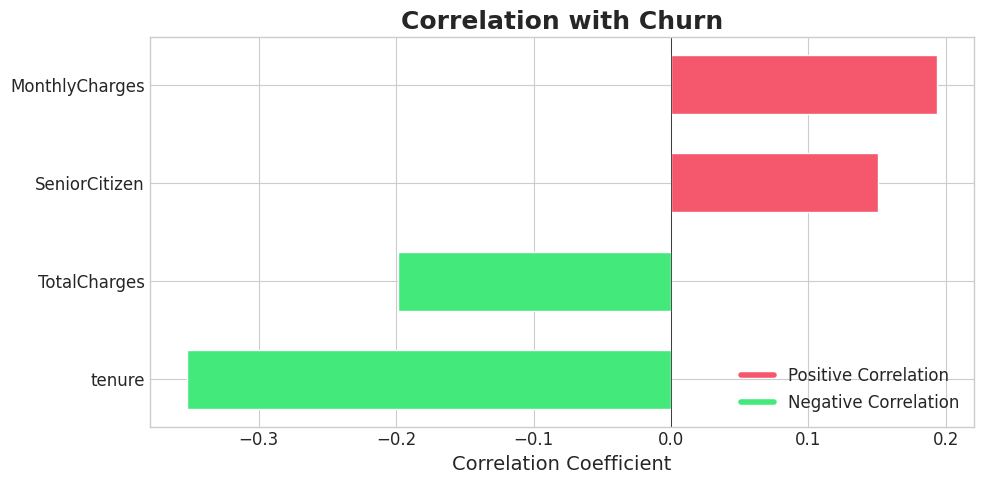

In [16]:
# Correlation with Churn
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values()
print("\nCorrelation with Churn:")
print(churn_corr.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['danger'] if v > 0 else COLORS['success'] for v in churn_corr.values]
ax.barh(churn_corr.index, churn_corr.values, color=colors, edgecolor='white', height=0.6)
ax.set_title('Correlation with Churn', fontsize=18, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Correlation Coefficient')
plt.legend(handles=[
    plt.Line2D([0], [0], color=COLORS['danger'], lw=4, label='Positive Correlation'),
    plt.Line2D([0], [0], color=COLORS['success'], lw=4, label='Negative Correlation')
], loc='lower right')
plt.tight_layout()
plt.show()

### 3.5 Key Insights from EDA

**High Churn Segments:**
- Month-to-month contracts (42.7% churn vs ~3% for two-year)
- Fiber optic internet (41.9% churn)
- Electronic check payment (45.3% churn)  
- No tech support / No online security (~42% churn each)
- Senior Citizens (41.7% churn)
- New customers (tenure < 12 months)

**Low Churn Segments:**
- Two-year contracts (~3% churn)
- DSL internet (~19% churn)
- Customers with add-on services (security, backup, support)
- Long-tenure customers (48+ months)